# JAX Optimization Check for 2du1 FT-HMC Evaluation

This notebook compares the existing PyTorch implementation and the experimental JAX backend for the **2du1 fixed field-transform evaluation path**. It does not train a model. Instead, it builds one small frozen U(1) field transform in memory, converts the same PyTorch weights to JAX arrays, and evaluates the FT-HMC force hot path.

The comparison covers three things:

1. Numerical consistency between PyTorch-compiled evaluation and JAX.
2. Compile time for PyTorch `torch.compile` force callables versus JAX `jit`.
3. Steady-state runtime after compilation.

The benchmark is intentionally checkpoint-free and small enough to finish in under five minutes on the current GPU workstation. PyTorch is tested with the same compile policy used by `2du1/evaluation/base/compare_fthmc.py`: only the force-path field transformation and Jacobian callables are compiled. JAX compiles the whole repeated force loop.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "pyproject.toml").exists() else cwd.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Could not find repo root from {cwd}"
PYTHON = REPO_ROOT / ".venv" / "bin" / "python"
if not PYTHON.exists():
    PYTHON = Path(sys.executable)

print(f"repo: {REPO_ROOT}")
print(f"python: {PYTHON}")

repo: /home/jinchen/git/anl/NTHMC
python: /home/jinchen/git/anl/NTHMC/.venv/bin/python


In [2]:
def benchmark_env() -> dict[str, str]:
    env = os.environ.copy()
    nvidia_roots = sorted((REPO_ROOT / ".venv" / "lib").glob("python*/site-packages/nvidia"))
    lib_dirs = sorted(path for root in nvidia_roots for path in root.glob("*/lib") if path.is_dir())
    if lib_dirs:
        existing = env.get("LD_LIBRARY_PATH", "")
        env["LD_LIBRARY_PATH"] = ":".join(str(path) for path in lib_dirs) + ((":" + existing) if existing else "")
    return env


BENCHMARK_CODE = r"""
import json
import sys
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import torch

repo = Path.cwd()
sys.path.insert(0, str(repo / "src"))

from nthmc.u1.field_transform import FieldTransformation
from nthmc.u1.jax_backend import JaxU1FieldTransformation, torch_field_transform_to_jax_params
from nthmc.u1.u1_fthmc import HMCU1FT

L = 8
BETA = 3.0
STEP = 1e-3
N_REPEAT = 16 if jax.default_backend() == "gpu" else 4


def sync_torch():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


torch.set_default_dtype(torch.float32)
torch.manual_seed(123)
torch_device = "cuda" if torch.cuda.is_available() else "cpu"

transform = FieldTransformation(
    L,
    device=torch_device,
    n_subsets=8,
    identity_init=True,
    model_tag="base",
    compile_enabled=False,
)
for model in transform.models:
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)

jax_transform = JaxU1FieldTransformation(torch_field_transform_to_jax_params(transform), lattice_size=L)
theta_cpu = torch.randn(2, L, L) * 0.1
theta_torch = theta_cpu.to(torch_device)
theta_jax = jnp.asarray(theta_cpu.numpy())

compile_setup_start = time.perf_counter()
transform.enable_eval_compile(backend="inductor")
torch_compile_setup_time = time.perf_counter() - compile_setup_start

torch_sampler = HMCU1FT(
    L,
    BETA,
    0,
    1,
    0.05,
    field_transformation=transform.field_transformation,
    compute_jac_logdet=transform.compute_jac_logdet,
    force_field_transformation=transform.field_transformation_compiled,
    force_compute_jac_logdet=transform.compute_jac_logdet_compiled,
    device=torch_device,
    tune_step_size=False,
)

sync_torch()
torch_compile_start = time.perf_counter()
torch_force = torch_sampler.new_force(theta_torch).detach().cpu().numpy()
sync_torch()
torch_force_compile_time = time.perf_counter() - torch_compile_start

with torch.no_grad():
    torch_forward = transform.field_transformation_compiled(theta_torch).detach().cpu().numpy()
    torch_jac = transform.compute_jac_logdet_compiled(theta_torch.unsqueeze(0)).detach().cpu().numpy()

jax_forward = np.asarray(jax_transform.field_transformation(theta_jax))
jax_jac = np.asarray(jax_transform.compute_jac_logdet(theta_jax[None, ...]))
jax_force = np.asarray(jax_transform.new_force(theta_jax, BETA))

sync_torch()
torch_start = time.perf_counter()
x_torch = theta_torch
for _ in range(N_REPEAT):
    x_torch = x_torch - STEP * torch_sampler.new_force(x_torch)
sync_torch()
torch_steady_time = time.perf_counter() - torch_start
torch_final = x_torch.detach().cpu().numpy()


def repeat_force(theta):
    def body(index, value):
        return value - STEP * jax_transform.new_force(value, BETA)
    return jax.lax.fori_loop(0, N_REPEAT, body, theta)

jax_compile_start = time.perf_counter()
compiled_repeat = jax.jit(repeat_force).lower(theta_jax).compile()
jax_compile_time = time.perf_counter() - jax_compile_start

jax_run_times = []
jax_final = None
for _ in range(3):
    run_start = time.perf_counter()
    jax_final = compiled_repeat(theta_jax)
    jax_final.block_until_ready()
    jax_run_times.append(time.perf_counter() - run_start)

payload = {
    "scenario": "2du1 fixed field-transform FT-HMC evaluation force path",
    "torch_device": torch_device,
    "jax_backend": jax.default_backend(),
    "jax_devices": [str(device) for device in jax.devices()],
    "lattice_size": L,
    "beta": BETA,
    "n_repeat": N_REPEAT,
    "max_abs_forward_error": float(np.max(np.abs(jax_forward - torch_forward))),
    "max_abs_jacobian_error": float(np.max(np.abs(jax_jac - torch_jac))),
    "max_abs_force_error": float(np.max(np.abs(jax_force - torch_force))),
    "max_abs_repeat_final_error": float(np.max(np.abs(np.asarray(jax_final) - torch_final))),
    "torch_compile_setup_time_sec": torch_compile_setup_time,
    "torch_force_compile_time_sec": torch_force_compile_time,
    "torch_compile_total_time_sec": torch_compile_setup_time + torch_force_compile_time,
    "jax_compile_time_sec": jax_compile_time,
    "torch_steady_time_sec": torch_steady_time,
    "jax_first_run_time_sec": jax_run_times[0],
    "jax_steady_time_sec": min(jax_run_times),
}
payload["steady_state_speedup_jax_over_torch_compile"] = payload["torch_steady_time_sec"] / payload["jax_steady_time_sec"]
print("RESULT_JSON=" + json.dumps(payload, sort_keys=True))
"""

completed = subprocess.run(
    [str(PYTHON), "-c", BENCHMARK_CODE],
    cwd=REPO_ROOT,
    env=benchmark_env(),
    text=True,
    capture_output=True,
    timeout=300,
)
if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr)
    raise RuntimeError(f"benchmark subprocess failed with code {completed.returncode}")

result_line = next(line for line in completed.stdout.splitlines() if line.startswith("RESULT_JSON="))
result = json.loads(result_line.removeprefix("RESULT_JSON="))
result

{'beta': 3.0,
 'jax_backend': 'gpu',
 'jax_compile_time_sec': 8.537414242979139,
 'jax_devices': ['cuda:0'],
 'jax_first_run_time_sec': 0.0246346490457654,
 'jax_steady_time_sec': 0.011737259104847908,
 'lattice_size': 8,
 'max_abs_force_error': 0.0,
 'max_abs_forward_error': 2.3283064365386963e-10,
 'max_abs_jacobian_error': 1.862645149230957e-09,
 'max_abs_repeat_final_error': 7.450580596923828e-09,
 'n_repeat': 16,
 'scenario': '2du1 fixed field-transform FT-HMC evaluation force path',
 'steady_state_speedup_jax_over_torch_compile': 16.439397507027415,
 'torch_compile_setup_time_sec': 0.5235383789986372,
 'torch_compile_total_time_sec': 10.019444836070761,
 'torch_device': 'cuda',
 'torch_force_compile_time_sec': 9.495906457072124,
 'torch_steady_time_sec': 0.19295346806757152}

In [3]:
print(result["scenario"])
print(f"PyTorch device: {result['torch_device']}")
print(f"JAX backend: {result['jax_backend']} on {result['jax_devices']}")
print(f"L={result['lattice_size']} beta={result['beta']} repeated force calls={result['n_repeat']}")
print()
print("1. Numerical consistency")
for key in ["max_abs_forward_error", "max_abs_jacobian_error", "max_abs_force_error", "max_abs_repeat_final_error"]:
    print(f"{key}: {result[key]:.3e}")
print()
print("2. Compile time")
print(f"PyTorch compile setup:       {result['torch_compile_setup_time_sec']:.4f} s")
print(f"PyTorch first force compile: {result['torch_force_compile_time_sec']:.4f} s")
print(f"PyTorch compile total:       {result['torch_compile_total_time_sec']:.4f} s")
print(f"JAX compile total:           {result['jax_compile_time_sec']:.4f} s")
print()
print("3. Steady run after compile")
print(f"PyTorch compiled force path: {result['torch_steady_time_sec']:.4f} s")
print(f"JAX compiled force loop:     {result['jax_steady_time_sec']:.4f} s")
print(f"JAX steady-state speedup:    {result['steady_state_speedup_jax_over_torch_compile']:.1f}x")

2du1 fixed field-transform FT-HMC evaluation force path
PyTorch device: cuda
JAX backend: gpu on ['cuda:0']
L=8 beta=3.0 repeated force calls=16

1. Numerical consistency
max_abs_forward_error: 2.328e-10
max_abs_jacobian_error: 1.863e-09
max_abs_force_error: 0.000e+00
max_abs_repeat_final_error: 7.451e-09

2. Compile time
PyTorch compile setup:       0.5235 s
PyTorch first force compile: 9.4959 s
PyTorch compile total:       10.0194 s
JAX compile total:           8.5374 s

3. Steady run after compile
PyTorch compiled force path: 0.1930 s
JAX compiled force loop:     0.0117 s
JAX steady-state speedup:    16.4x


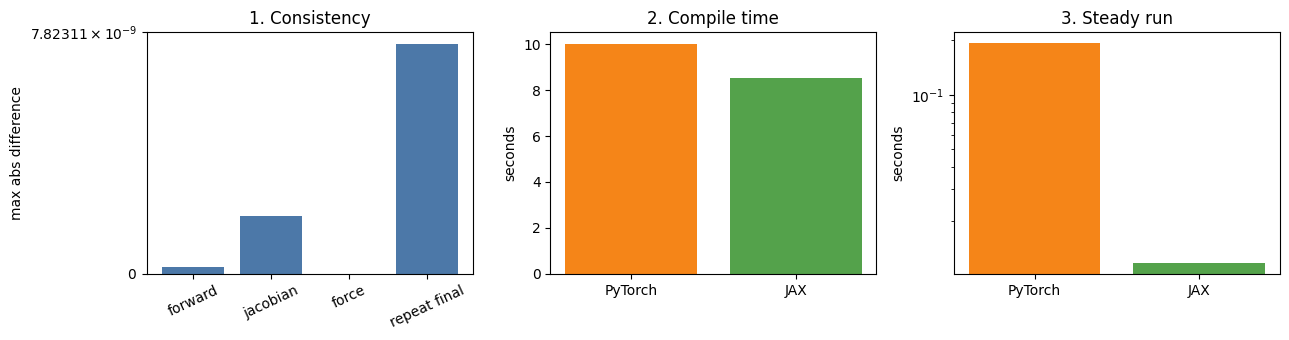

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

error_names = ["forward", "jacobian", "force", "repeat final"]
errors = [
    result["max_abs_forward_error"],
    result["max_abs_jacobian_error"],
    result["max_abs_force_error"],
    result["max_abs_repeat_final_error"],
]
axes[0].bar(error_names, errors, color="#4c78a8")
axes[0].set_yscale("symlog", linthresh=1e-8)
axes[0].set_ylabel("max abs difference")
axes[0].set_title("1. Consistency")
axes[0].tick_params(axis="x", rotation=25)

compile_names = ["PyTorch", "JAX"]
compile_times = [result["torch_compile_total_time_sec"], result["jax_compile_time_sec"]]
axes[1].bar(compile_names, compile_times, color=["#f58518", "#54a24b"])
axes[1].set_ylabel("seconds")
axes[1].set_title("2. Compile time")

steady_names = ["PyTorch", "JAX"]
steady_times = [result["torch_steady_time_sec"], result["jax_steady_time_sec"]]
axes[2].bar(steady_names, steady_times, color=["#f58518", "#54a24b"])
axes[2].set_yscale("log")
axes[2].set_ylabel("seconds")
axes[2].set_title("3. Steady run")

fig.tight_layout()
plt.show()

Interpretation: PyTorch's existing evaluation compile path accelerates only the force callables. JAX pays a larger one-time compile cost because it compiles the repeated force loop as a single static program, but the compiled steady-state runtime is much lower for this fixed-shape 2du1 evaluation workload.